In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics import pairwise_distances

# Klasterovanje oglasa za posao

U ovom notebook-u zapocinjemo fazu klasterovanja nad prethodno pripremljenim skupom LinkedIn Job Postings.

Prethodno je izvrseno spajanje relevantnih tabela, uklanjanje nepotrebnih atributa, obrada nedostajucih vrednosti, kodiranje kategorickih atributa, obrada tekstualnog atributa `title`, logaritamska transformacija numerickih atributa i standardizacija celog skupa.

Za klasterovanje su pripremljene tri verzije podataka:

- `X_scaled` - standardizovan skup sa svim atributima
- `X_pca_70` - PCA reprezentacija koja zadrzava 70% varijanse
- `X_pca_80` - PCA reprezentacija koja zadrzava 80% varijanse

Cilj je da se primeni vise algoritama klasterovanja, uporede rezultati na razlicitim reprezentacijama podataka i proceni kvalitet dobijenih klastera pomocu internih metrika evaluacije.

## KMeans klasterovanje

Kao prvi algoritam primenjujemo KMeans. Ovaj algoritam zahteva da se unapred zada broj klastera, pa cemo testirati vise vrednosti parametra `k` i uporediti rezultate pomocu internih metrika evaluacije.
Posto skup ima veliki broj redova, Silhouette Score racunamo nad uzorkom podataka.

In [2]:
X_scaled = pd.read_csv("../../data/data_full_scaled.csv")
X_pca_70 = pd.read_csv("../../data/X_pca_70.csv")
X_pca_80 = pd.read_csv("../../data/X_pca_80.csv")
X_pca_50 = pd.read_csv("../../data/X_pca_50.csv")
X_pca_30 = pd.read_csv("../../data/X_pca_30.csv")

In [3]:
X_scaled = X_scaled.drop(columns=["Unnamed: 0"])

In [4]:
datasets = {
    "X_scaled": X_scaled,
    "X_pca_80": X_pca_80,
    "X_pca_70": X_pca_70,
    "X_pca_50": X_pca_50,
    "X_pca_30": X_pca_30
}

for name, X in datasets.items():
    print(name, X.shape)

X_scaled (123849, 425)
X_pca_80 (123849, 163)
X_pca_70 (123849, 143)
X_pca_50 (123849, 101)
X_pca_30 (123849, 59)


## Formiranje uzorka za evaluaciju modela

Pojedini algoritmi klasterovanja imaju znacajne zahteve u pogledu vremena izvrsavanja i memorije, narocito kada se primenjuju nad skupom koji sadrzi vise od 120.000 instanci.

Zbog toga se za poredjenje razlicitih vrednosti parametara koristi slucajni uzorak od 10.000 instanci. Uzorak se formira jednom i zatim koristi za sve reprezentacije podataka kako bi rezultati bili medjusobno uporedivi.

Koriscenjem iste liste indeksa obezbedjuje se da svaki algoritam i svaka PCA reprezentacija budu evaluirani nad potpuno istim instancama. Na taj nacin razlike u rezultatima poticu iskljucivo od karakteristika modela i reprezentacije podataka, a ne od razlicitih uzoraka.

In [5]:
sample_size = min(10000, X_scaled.shape[0])
random_state = 42

sample_idx = np.random.RandomState(random_state).choice(
    X_scaled.shape[0],
    size=sample_size,
    replace=False
)

datasets_sample = {
    name: X.iloc[sample_idx]
    for name, X in datasets.items()
}

## Primena KMeans algoritma za razlicite vrednosti parametra k

U ovoj celiji KMeans algoritam se primenjuje nad svim pripremljenim reprezentacijama podataka: kompletnim skaliranim skupom i PCA skupovima sa 30, 50, 70 i 80 komponenti.

Za svaku reprezentaciju testiraju se vrednosti broja klastera od 2 do 10. Nakon treniranja modela cuvaju se dve metrike: inertia i Silhouette Score.

Inertia meri ukupnu udaljenost instanci od centroida svojih klastera i koristi se za Elbow metodu. Silhouette Score meri koliko su instance slicne svom klasteru u odnosu na druge klastere i koristi se za izbor najkvalitetnije podele.

Modeli se treniraju nad prethodno formiranim uzorkom, kako bi se smanjili vreme izvrsavanja i memorijska zahtevnost, ali i zadrzala uporedivost rezultata izmedju razlicitih reprezentacija.

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import pandas as pd
import numpy as np


k_values = range(2, 11)
kmeans_results = []

for dataset_name, X in datasets_sample.items():
    for k in k_values:
        kmeans = KMeans(
            n_clusters=k,
            random_state=42,
            n_init=10
        )
        
        labels = kmeans.fit_predict(X)
        
        inertia = kmeans.inertia_
        silhouette = silhouette_score(X, labels)
        
        kmeans_results.append({
            "dataset": dataset_name,
            "k": k,
            "inertia": inertia,
            "silhouette_score": silhouette
        })

kmeans_results = pd.DataFrame(kmeans_results)
kmeans_results

,dataset,k,inertia,silhouette_score
0,X_scaled,2,2.061415e+06,0.011187
1,X_scaled,3,2.059672e+06,0.006325
2,X_scaled,4,2.040963e+06,0.014761
3,X_scaled,5,2.033770e+06,0.013131
4,X_scaled,6,2.025490e+06,-0.026096
5,X_scaled,7,2.010591e+06,-0.050420
6,X_scaled,8,2.001155e+06,-0.019641
7,X_scaled,9,1.993928e+06,-0.022410
8,X_scaled,10,1.982802e+06,-0.033510
9,X_pca_80,2,1.647881e+06,0.013567


In [ ]:
best_kmeans_results = (
    kmeans_results
    .sort_values("silhouette_score", ascending=False)
    .reset_index(drop=True)
)

best_kmeans_results.head(10)

,dataset,k,inertia,silhouette_score
0,X_pca_30,9,5.531927e+05,0.047727
1,X_pca_30,10,5.454280e+05,0.041260
2,X_pca_30,3,6.024847e+05,0.040987
3,X_pca_30,5,5.848801e+05,0.036657
4,X_pca_30,2,6.112338e+05,0.035835
5,X_pca_30,6,5.766445e+05,0.034171
6,X_pca_30,8,5.610351e+05,0.034163
7,X_pca_50,7,9.862855e+05,0.030287
8,X_pca_70,9,1.384725e+06,0.029063
9,X_pca_80,8,1.588048e+06,0.028403


In [ ]:
best_row = best_kmeans_results.iloc[0]

best_dataset_name = best_row["dataset"]
best_k = int(best_row["k"])
best_score = best_row["silhouette_score"]

print("Najbolji dataset:", best_dataset_name)
print("Najbolji k:", best_k)
print("Najbolji Silhouette Score:", best_score)

Najbolji dataset: X_pca_30
Najbolji k: 9
Najbolji Silhouette Score: 0.04772696519624784


In [ ]:
X_best = datasets[best_dataset_name]

final_kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

final_labels = final_kmeans.fit_predict(X_best)

In [ ]:
cluster_sizes = pd.Series(final_labels).value_counts().sort_index()

cluster_sizes_df = pd.DataFrame({
    "cluster": cluster_sizes.index,
    "count": cluster_sizes.values,
    "percentage": cluster_sizes.values / len(final_labels) * 100
})

cluster_sizes_df

,cluster,count,percentage
0,0,1451,1.171588
1,1,43241,34.914291
2,2,14874,12.009786
3,3,3617,2.920492
4,4,14184,11.452656
5,5,9462,7.639949
6,6,815,0.658059
7,7,4065,3.282223
8,8,32140,25.950956


## Analiza rezultata

Rezultati pokazuju da primena PCA redukcije dimenzionalnosti pozitivno utice na performanse KMeans algoritma. Najnize vrednosti Silhouette Score metrike ostvarene su nad kompletnim skaliranim skupom podataka, dok se najbolji rezultati postizu nakon redukcije dimenzionalnosti.

Kod kompletnog skupa atributa maksimalna vrednost Silhouette Score iznosi svega 0.015, sto ukazuje da KMeans tesko pronalazi jasno razdvojene grupe u prostoru visoke dimenzionalnosti. Ovo je ocekivano, jer veliki broj atributa moze sadrzati redundantne informacije i sum koji otezavaju formiranje kompaktnih klastera.

Sa smanjenjem dimenzionalnosti dolazi do postepenog poboljsanja rezultata. Najbolje performanse ostvarene su nad reprezentacijom sa 30 glavnih komponenti, gde je za k = 9 dobijen najveci Silhouette Score od 0.048.

Takav rezultat sugerise da prvih 30 glavnih komponenti uspesno zadrzava najvaznije obrasce u podacima, dok istovremeno uklanja deo suma prisutnog u originalnom prostoru atributa. Dodavanje veceg broja komponenti ne dovodi do dodatnog poboljsanja kvaliteta klastera, vec naprotiv, rezultati postaju nesto losiji.

Iako PCA znacajno poboljsava rezultate u odnosu na originalni skup podataka, apsolutne vrednosti Silhouette Score metrike ostaju relativno niske. To ukazuje da skup ne poseduje izrazito prirodnu strukturu sa jasno odvojenim grupama, vec da izmedju instanci postoji znacajno preklapanje.

Na osnovu ostvarenih rezultata moze se zakljuciti da je PCA reprezentacija sa 30 komponenti najpogodnija za dalju primenu KMeans algoritma i detaljniju analizu klastera.

## Elbow metoda

SSE mera predstavlja sumu kvadratnih rastojanja tacaka od centroida klastera kome pripadaju. Cilj je da ova vrednost bude sto manja.

Medjutim, SSE prirodno opada kada se broj klastera povecava. Zato trazimo tacku prevoja, odnosno vrednost k nakon koje dalje povecanje broja klastera ne donosi znacajno smanjenje SSE mere.

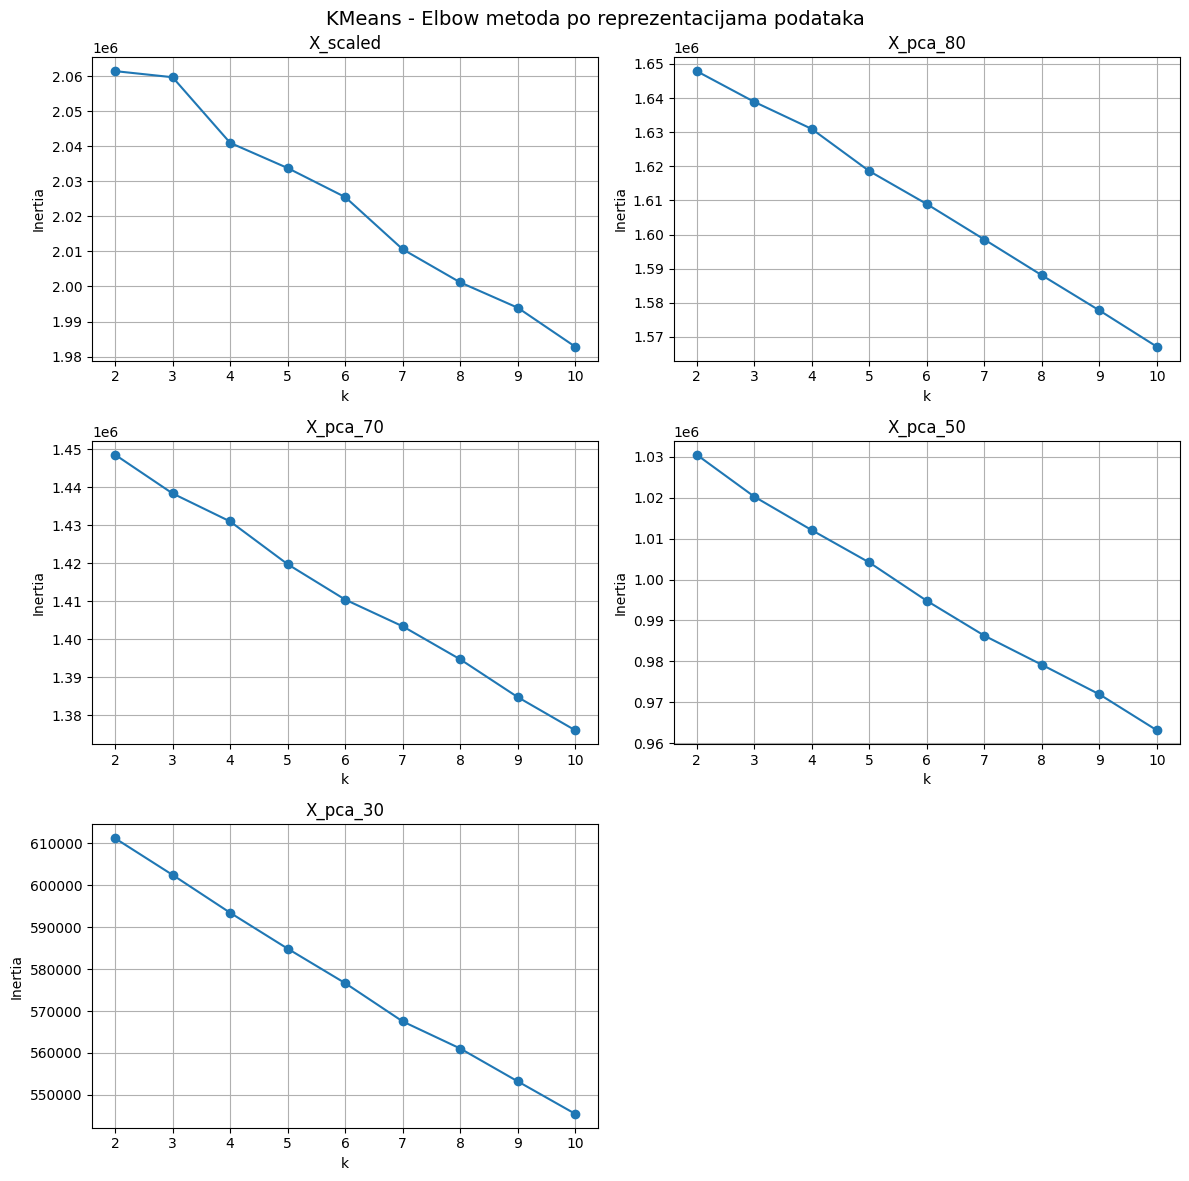

In [ ]:
import matplotlib.pyplot as plt
import math

datasets = kmeans_results["dataset"].unique()

n_cols = 2
n_rows = math.ceil(len(datasets) / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(12, 4 * n_rows)
)

axes = axes.flatten()

for i, dataset_name in enumerate(datasets):

    data = kmeans_results[
        kmeans_results["dataset"] == dataset_name
    ]

    axes[i].plot(
        data["k"],
        data["inertia"],
        marker="o"
    )

    axes[i].set_title(dataset_name)
    axes[i].set_xlabel("k")
    axes[i].set_ylabel("Inertia")
    axes[i].grid(True)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle(
    "KMeans - Elbow metoda po reprezentacijama podataka",
    fontsize=14
)

plt.tight_layout()
plt.show()

Na osnovu Elbow metode ne uocava se jasno izrazen lakat ni za jednu od posmatranih reprezentacija podataka. Vrednost inertia-e se postepeno smanjuje sa povecanjem broja klastera, sto znaci da nije moguce jednoznacno odrediti optimalan broj klastera samo na osnovu ove metode.

Zbog toga se izbor broja klastera ne zasniva iskljucivo na Elbow metodi, vec se dodatno posmatraju Silhouette Score i interpretabilnost dobijenih klastera.

## Silhouette analiza

Silhouette koeficijent meri koliko je svaka instanca slicna instancama iz svog klastera u odnosu na instance iz najblizeg drugog klastera.

Vrednost se nalazi u intervalu od -1 do 1. Vise vrednosti ukazuju na bolje grupisanje, odnosno na kompaktnije i bolje razdvojene klastere.

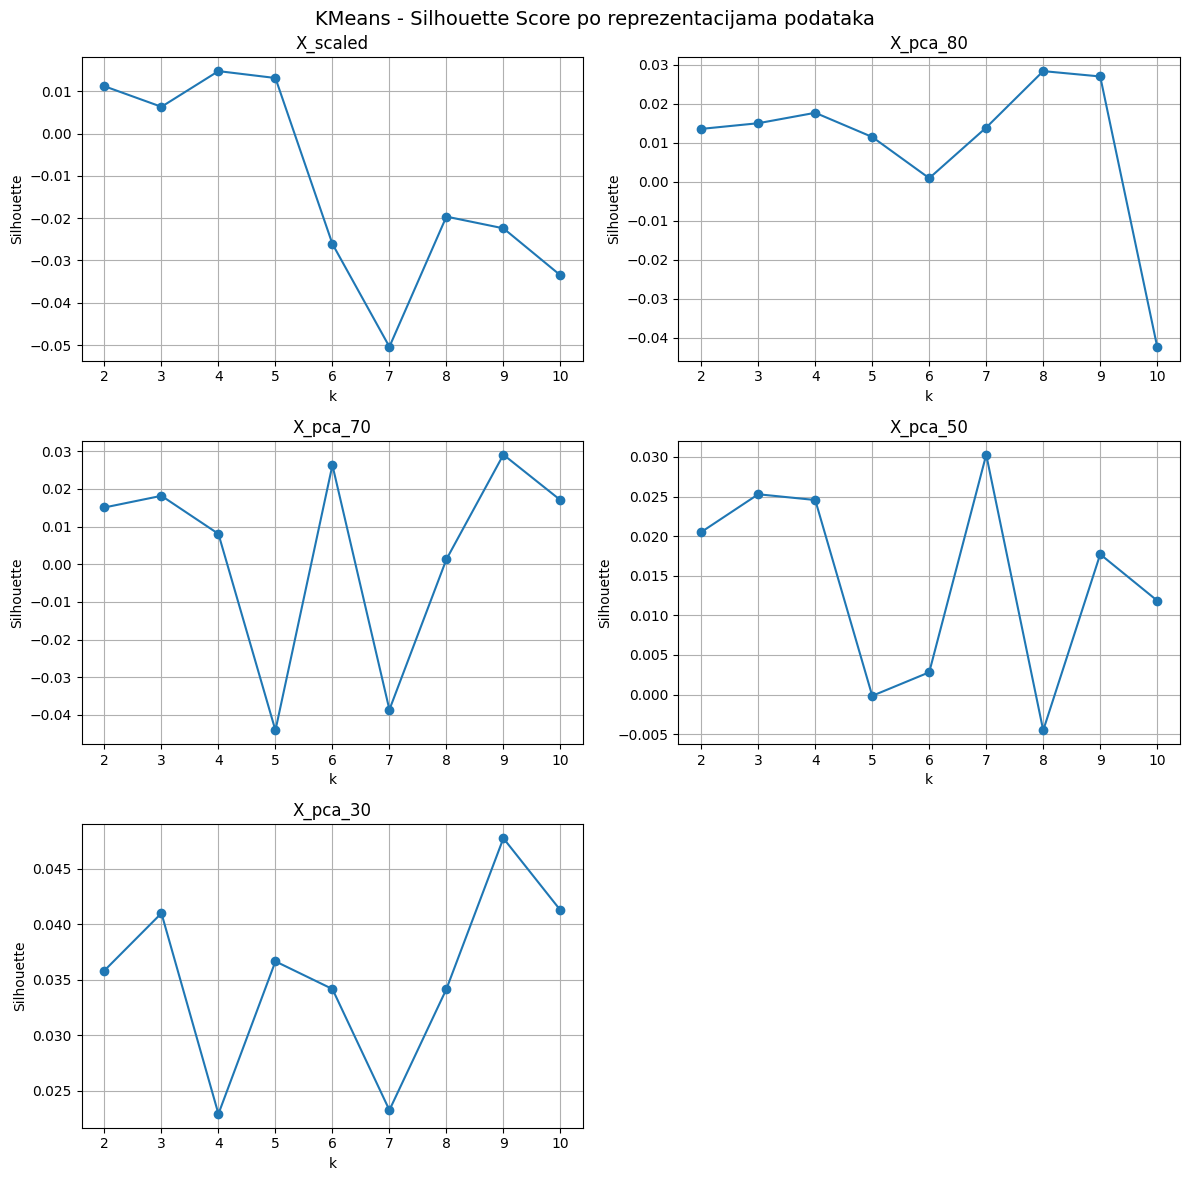

In [ ]:
import matplotlib.pyplot as plt
import math

datasets_names = kmeans_results["dataset"].unique()

n_cols = 2
n_rows = math.ceil(len(datasets) / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(12, 4 * n_rows)
)

axes = axes.flatten()

for i, dataset_name in enumerate(datasets_names):

    data = kmeans_results[
        kmeans_results["dataset"] == dataset_name
    ]

    axes[i].plot(
        data["k"],
        data["silhouette_score"],
        marker="o"
    )

    axes[i].set_title(dataset_name)
    axes[i].set_xlabel("k")
    axes[i].set_ylabel("Silhouette")
    axes[i].grid(True)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle(
    "KMeans - Silhouette Score po reprezentacijama podataka",
    fontsize=14
)

plt.tight_layout()

plt.show()

## Analiza uticaja broja glavnih komponenti na kvalitet klasterovanja

Prethodni eksperimenti pokazali su da KMeans ostvaruje bolje rezultate nakon redukcije dimenzionalnosti pomocu PCA transformacije. Takodje je uoceno da smanjenje broja komponenti dovodi do postepenog rasta Silhouette Score metrike.

Zbog toga se sprovodi dodatna analiza sa manjim brojem glavnih komponenti. Za svaku PCA reprezentaciju od 3 do 10 komponenti pronalazi se optimalan broj klastera u opsegu od 3 do 10, a zatim se belezi najbolja ostvarena vrednost Silhouette Score metrike.

Cilj ove analize je da se ispita da li agresivnija redukcija dimenzionalnosti moze dodatno poboljsati separaciju klastera i omoguci izbor pogodnije reprezentacije podataka za dalji rad.

In [6]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

results = []

for n_components in [3, 4, 5, 6, 7, 8, 9, 10]:

    pca = PCA(
        n_components=n_components,
        random_state=42
    )

    X_pca = pca.fit_transform(X_scaled)

    X_sample = X_pca[sample_idx]

    best_silhouette = -1
    best_k = None

    for k in range(2, 11):

        model = KMeans(
            n_clusters=k,
            random_state=42,
            n_init=10
        )

        labels = model.fit_predict(X_sample)

        score = silhouette_score(
            X_sample,
            labels
        )

        if score > best_silhouette:
            best_silhouette = score
            best_k = k

    results.append({
        "n_components": n_components,
        "explained_variance": pca.explained_variance_ratio_.sum(),
        "best_k": best_k,
        "best_silhouette": best_silhouette
    })

results = pd.DataFrame(results)

results

,n_components,explained_variance,best_k,best_silhouette
0,3,0.026899,4,0.335934
1,4,0.032507,3,0.289160
2,5,0.038036,4,0.262906
3,6,0.043420,5,0.249918
4,7,0.048697,5,0.221006
5,8,0.053797,7,0.207538
6,9,0.058866,7,0.189450
7,10,0.063909,10,0.199788


## Analiza rezultata

Rezultati pokazuju da se kvalitet klasterovanja dodatno poboljsava sa smanjenjem broja glavnih komponenti. Ovo potvrdjuje prethodnu pretpostavku da znacajan deo dimenzija u originalnom prostoru ne doprinosi formiranju kvalitetnih klastera, vec uglavnom uvodi dodatni sum.

Najbolji rezultati ostvareni su kod reprezentacija sa veoma malim brojem komponenti, sto ukazuje da se najvaznije informacije za grupisanje instanci nalaze u prvih nekoliko glavnih komponenti. Istovremeno, veci broj komponenti zadrzava dodatnu varijansu koja nije nuzno korisna za potrebe klasterovanja.

Ovakvo ponasanje je cesto kod skupova sa velikim brojem atributa, gde PCA uklanja redundantne informacije i projektuje podatke u prostor u kome su dominantni obrasci izrazeni jasnije nego u originalnoj reprezentaciji.

Na osnovu dobijenih rezultata moze se zakljuciti da prethodno sacuvane PCA reprezentacije sa 30, 50, 70 i 80 komponenti nisu optimalne za KMeans algoritam. Zbog toga se analiza nastavlja nad reprezentacijama sa manjim brojem glavnih komponenti, koje pokazuju veci potencijal za formiranje kvalitetnijih klastera.

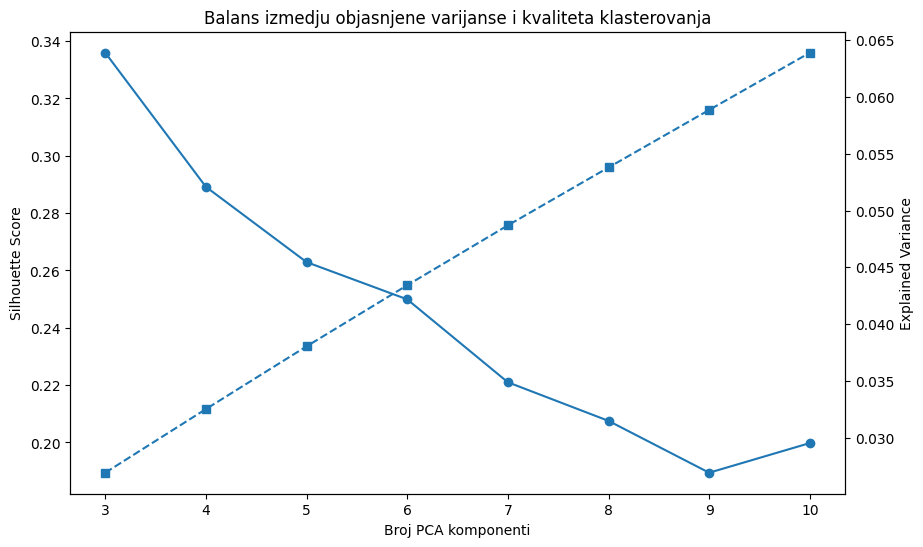

In [7]:
fig, ax1 = plt.subplots(figsize=(10,6))

ax1.plot(
    results["n_components"],
    results["best_silhouette"],
    marker="o",
    label="Silhouette"
)

ax1.set_xlabel("Broj PCA komponenti")
ax1.set_ylabel("Silhouette Score")

ax2 = ax1.twinx()

ax2.plot(
    results["n_components"],
    results["explained_variance"],
    marker="s",
    linestyle="--",
    label="Explained Variance"
)

ax2.set_ylabel("Explained Variance")

plt.title(
    "Balans izmedju objasnjene varijanse i kvaliteta klasterovanja"
)

plt.show()

In [8]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

pca_3 = PCA(
    n_components=3,
    random_state=42
)

X_pca_3 = pca_3.fit_transform(X_scaled)

X_sample_pca_3 = X_pca_3[sample_idx]

kmeans_pca_3 = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

labels_kmeans_pca_3 = kmeans_pca_3.fit_predict(
    X_sample_pca_3
)

pd.Series(labels_kmeans_pca_3).value_counts()

0    4192
1    2626
3    1770
2    1412
Name: count, dtype: int64

In [9]:
X_kmeans_pca_3 = X_sample_pca_3

## Vizualizacija dobijenih klastera

Radi lakseg tumacenja rezultata, klasteri su prikazani u trodimenzionalnom prostoru formiranom od prve tri glavne komponente PCA transformacije.

Svaka tacka predstavlja jedan oglas za posao, dok boja oznacava klaster kojem je instanca dodeljena od strane KMeans algoritma. Na ovaj nacin moguce je steci intuitivan uvid u raspored klastera, njihovu velicinu i medjusobnu separaciju.

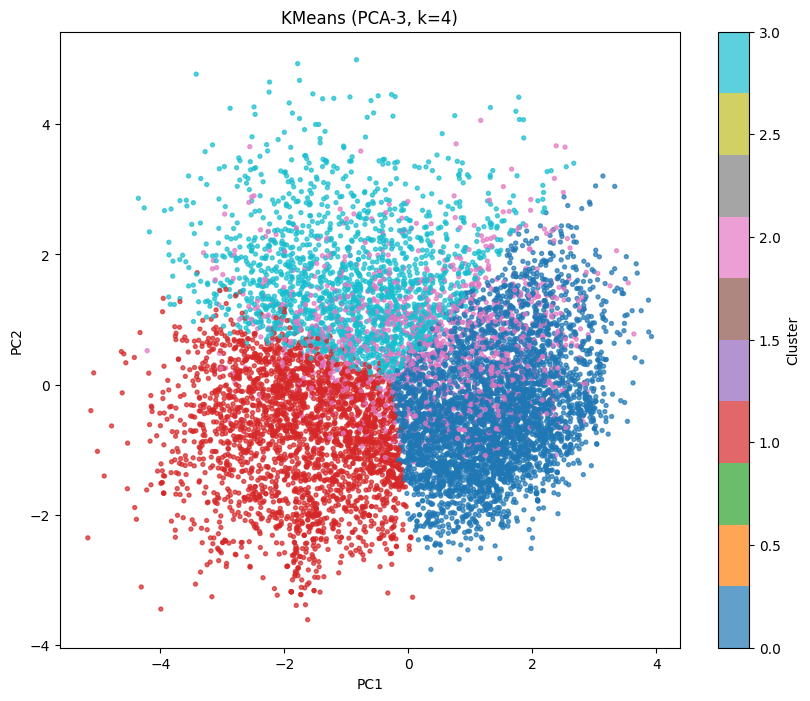

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

scatter = plt.scatter(
    X_kmeans_pca_3[:,0],
    X_kmeans_pca_3[:,1],
    c=labels_kmeans_pca_3,
    cmap="tab10",
    s=8,
    alpha=0.7
)

plt.title("KMeans (PCA-3, k=4)")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.colorbar(scatter, label="Cluster")

plt.show()

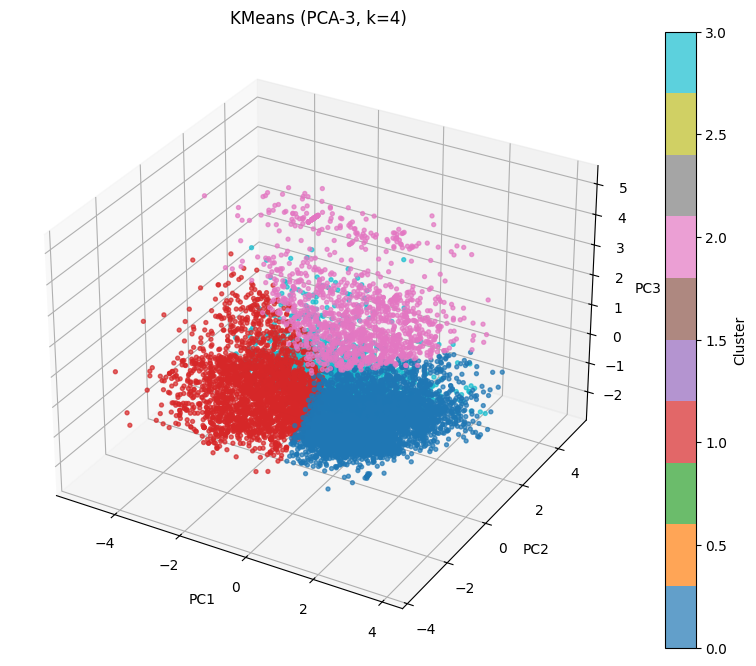

In [10]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection="3d")

scatter = ax.scatter(
    X_kmeans_pca_3[:,0],
    X_kmeans_pca_3[:,1],
    X_kmeans_pca_3[:,2],
    c=labels_kmeans_pca_3,
    cmap="tab10",
    s=8,
    alpha=0.7
)

ax.set_title("KMeans (PCA-3, k=4)")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")

plt.colorbar(scatter, label="Cluster")
plt.show()

### Zakljucak vizuelne analize

Na osnovu trodimenzionalne vizuelizacije moze se uociti da KMeans uspesno identifikuje nekoliko jasno definisanih grupa u prostoru prvih PCA komponenti. Klasteri pokazuju odredjeni stepen preklapanja na granicama, sto je i ocekivano s obzirom na slozenost i visoku dimenzionalnost originalnog skupa podataka.

Posebno je znacajno da nijedan klaster ne predstavlja samo mali broj izdvojenih instanci, vec svi obuhvataju znacajan deo podataka.

Vizuelna struktura klastera ukazuje da model ne vrsi samo izdvajanje atipicnih primera, vec zaista pronalazi vise grupa sa razlicitim karakteristikama. Zbog toga se dobijeni klasteri mogu smatrati dovoljno stabilnim i interpretabilnim za dalju analizu atributa i evaluaciju poslovnog znacaja svake grupe.

In [19]:
pca_3 = PCA(
    n_components=3,
    random_state=42
)

X_pca_3 = pca_3.fit_transform(X_scaled)

kmeans_pca_3 = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

labels_kmeans_pca_3 = kmeans_pca_3.fit_predict(X_pca_3)

Cuvanje labela radi kasnije evaluacije.

In [ ]:
pd.Series(labels_kmeans_pca_3).to_csv(
    "../../models/kmeans_labels.csv",
    index=False
)